In [5]:
from dotenv import load_dotenv
import os
from langchain_core.messages import ToolMessage, BaseMessage
import importlib
from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    AnyMessage,
    BaseMessage, 
    AIMessage, 
    HumanMessage, 
    SystemMessage,
    ToolMessage,
    ToolCall
    )

In [2]:
load_dotenv()

llm = ChatOpenAI(model = "gpt-4o-mini")

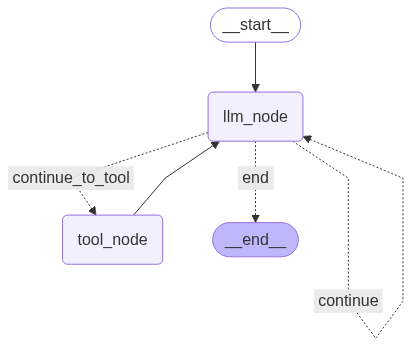

In [13]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [6]:
create_character.invoke({
     "character_name": "Sven Nord",
    "age" : 38,
    "gender" : 'M',
    "disposition" : "Inquisitve",
    "relationships_out" :  {"Luna": "Random person he met", "Swedenborg": "Suspects him being the culprit"},
    "relationships_in" :{ "Luna": "Random person she met", "Swedenborg": "Suspects him suspecting him being the culprit"},
    }
    )

'caracter Sven Nord created'

In [29]:
simple_tool_message = ToolMessage(content="this is a tool message", tool_call_id="id")
llm._get_request_payload([simple_tool_message])

{'model': 'gpt-4o-mini',
 'stream': False,
 'temperature': 0.2,
 'messages': [{'content': 'this is a tool message',
   'role': 'tool',
   'tool_call_id': 'id'}]}

In [61]:
conn = sqlite3.connect("checkpoints.sqlite")
checkpointer = SqliteSaver(conn)

In [ ]:
graph = builder.compile(checkpointer= checkpointer)

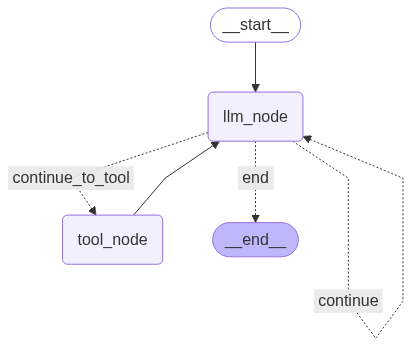

In [58]:
graph

In [ ]:
# state


In [4]:
from agent_tools.characters import create_character

In [5]:
create_character.invoke({
    "character_name" : "Rory the Menace",
    "age" : 18,
    "gender" : "M",
    "disposition" : "Hodlum",
    "relationships_out" : {"Luna" : "Secret Crush" ,"Swedenborg" : "Thinks Swedenborg is a wuss",
                         "Captain Flask": "Disregard" },
    "relationships_in" : {"Luna" : "Sees him as a violent thugh" ,"Swedenborg" : "Intimidated",
                         "Captain Flask": "Good for nothin street thug" }
    })

'caracter Rory the Menace created'

In [ ]:
from sqlalchemy import create_engine
from sqlalchemy.sql import text

engine = create_engine('sqlite:///db/stageplay/state.db', echo=False)
with engine.connect() as conn:
    try:
        conn.execute(text("CREATE TABLE IF NOT EXISTS test (id INTEGER PRIMARY KEY, name TEXT)"))
        conn.execute(text("INSERT INTO test (name) VALUES ('test')"))
        conn.commit()
        print("Write operation successful. Database is not read-only.")
    except Exception as e:
        print(f"Error: {e}")

Write operation successful. Database is not read-only.


In [8]:
engine = create_engine('sqlite:///db/stageplay/state.db', echo=False)
with engine.connect() as conn:
    try:
        res = conn.execute(text("select * from relationships"))
        # conn.commit()
        print(res.fetchall())
    except Exception as e:
        print(f"Error: {e}")

[(1, 'Luna', 'Swedenborg', 'Aimicable'), (2, 'Luna', 'Captain Flask', 'Veneration and slighthly frightened'), (3, 'Swedenborg', 'Luna', 'Unrequited Infatuation'), (4, 'Swedenborg', 'Captain Flask', 'Veneration'), (5, 'Captain Flask', 'Luna', 'Reminds him of lost youth and daughter that never was'), (6, 'Captain Flask', 'Swedenborg', 'Sees him as a young man with lots of potential'), (7, 'Rory the Menace', 'Luna', 'Secret Crush'), (8, 'Rory the Menace', 'Swedenborg', 'Thinks Swedenborg is a wuss'), (9, 'Rory the Menace', 'Captian Flask', 'Disregard'), (10, 'Rory the Menace', 'Luna', 'Sees him as a violent thugh'), (11, 'Rory the Menace', 'Swedenborg', 'Intimidated'), (12, 'Rory the Menace', 'Captian Flask', 'Good for nothin street thug')]


In [ ]:
from sqlalchemy import create_engine, Column, Integer, String 
import db.handler as db
from sqlalchemy.orm import sessionmaker
from sqlalchemy.inspection import inspect

In [4]:
from db.handler import get_roster

print(get_roster())

[{'name': 'Luna', 'gender': 'F', 'age': 16, 'disposition': 'Sassy', 'relationships': [{'Swedenborg': 'Aimicable'}, {'Captain Flask': 'Veneration and slighthly frightened'}, {'Rory the Menace': 'Sees him as a violent thugh'}]}, {'name': 'Swedenborg', 'gender': 'M', 'age': 15, 'disposition': 'Melancholic', 'relationships': [{'Luna': 'Unrequited Infatuation'}, {'Captain Flask': 'Veneration'}, {'Rory the Menace': 'Intimidated'}]}, {'name': 'Captain Flask', 'gender': 'M', 'age': 55, 'disposition': 'Seasoned seafaring captain', 'relationships': [{'Luna': 'Reminds him of lost youth and daughter that never was'}, {'Swedenborg': 'Sees him as a young man with lots of potential'}, {'Rory the Menace': 'Good for nothin street thug'}]}, {'name': 'Rory the Menace', 'gender': 'M', 'age': 18, 'disposition': 'Hodlum', 'relationships': [{'Luna': 'Secret Crush'}, {'Swedenborg': 'Thinks Swedenborg is a wuss'}, {'Captain Flask': 'Disregard'}]}]


In [6]:
roster = get_roster()

In [18]:
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langchain_core.runnables import RunnableConfig
from agent_graph import StagePlayWriter,input_message, StagePlayState

conn_checkptr = "db/graph_checkpoints/checkpoints.db"
graph_config: RunnableConfig = RunnableConfig({"configurable": {"thread_id": "new_thread_id_2"}})

In [19]:
playwriter = StagePlayWriter(
    llm=llm,
    themes= """Loss of innocence, Becoming Psychologically whole, Jungian Psychology, Bildung""",
    vibe= """Subtly, Weird and funky""",
    setting= "Tam Tamoree, fictional town in German Bavaria",
    number_of_chapters= 4
)
conn_checkptr = "db/graph_checkpoints/checkpoints.db"


In [20]:
async with AsyncSqliteSaver.from_conn_string(conn_checkptr) as checkpointer:
    graph = playwriter.build_graph(checkpointer) 
    print(graph.get_state(checkpointer))


ValueError: Found edge ending at unknown node `llm_node`